# **FINAL PROJECT FUNDAMENTALS OF DEEP LEARNING 2026**

# Part 1: FLICKR IMAGE CLASSIFICATION

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Activation, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
import os

# Set constants from class guidelines
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
# TRAIN_CSV = '../data/train_image_class.csv'
# VALID_CSV = '../data/valid_image_class.csv'
IMAGES_DIR = 'data/'

## 1. Loading and Preprocessing the Dataset

The goal of this step is to load the Flickr8k dataset and prepare the images for training deep learning models. This involves mapping images to their respective categories (animals, objects, people, scenes, and others), resizing them to a uniform shape, and normalizing the pixel values.

In [ ]:
# 1. Define paths relative to the 'src' directory
DATA_DIR = 'data/'
TRAIN_CSV = os.path.join(DATA_DIR, 'train_image_class.csv')
VALID_CSV = os.path.join(DATA_DIR, 'valid_image_class.csv')

# 2. Load the CSV data
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

print(f"Number of training samples: {len(train_df)}")
print(f"Number of validation samples: {len(valid_df)}")
print(f"Categories: {train_df['Label'].unique()}")

# 3. Define Image Data Generators
# Rescale pixel values to [0, 1]
datagen = ImageDataGenerator(rescale=1./255)

# 4. Parameters for loading
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training data
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATA_DIR,
    x_col="Image Path",
    y_col="Label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

# Load validation data
valid_generator = datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=DATA_DIR,
    x_col="Image Path",
    y_col="Label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Verify the class indices
print("\nClass Indices Mapping:")
print(train_generator.class_indices)

Number of training samples: 6114
Number of validation samples: 1529
Categories: ['people' 'animals' 'others' 'objects' 'scenes']
Found 6114 validated image filenames belonging to 5 classes.
Found 1529 validated image filenames belonging to 5 classes.

Class Indices Mapping:
{'animals': 0, 'objects': 1, 'others': 2, 'people': 3, 'scenes': 4}


### a. Train two different Multi-layer perceptron networks

For the MLP models, we have to flatten the 2D images into a 1D array before they can enter the Dense layers.

**MLP 1 (Baseline)**: We define a simple model with two hidden layers using 64 and 32 neurons with ReLU activation.

**MLP 2 (Deeper)**: We define a larger model with 128, 64, and 32 neurons. We also add a Dropout layer (30%) because MLPs with many parameters are very likely to overfit on image data.

In [ ]:
# Build MLP 1
mlp1 = Sequential()
mlp1.add(Flatten(input_shape=(224, 224, 3)))
mlp1.add(Dense(64, activation='relu'))
mlp1.add(Dense(32, activation='relu'))
mlp1.add(Dense(5, activation='softmax'))

# Build MLP 2
mlp2 = Sequential()
mlp2.add(Flatten(input_shape=(224, 224, 3)))
mlp2.add(Dense(128, activation='relu'))
mlp2.add(Dropout(0.3))
mlp2.add(Dense(64, activation='relu'))
mlp2.add(Dense(32, activation='relu'))
mlp2.add(Dense(5, activation='softmax'))

mlp1.summary()
mlp2.summary()

C:\Users\Source\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     9,633,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,636,101 (36.76 MB)

 Trainable params: 9,636,101 (36.76 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,278,213 (73.54 MB)

 Trainable params: 19,278,213 (73.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
mlp1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training MLP 1...")
history1 = mlp1.fit(train_generator, validation_data=valid_generator, epochs=10)

print("Training MLP 2...")
history2 = mlp2.fit(train_generator, validation_data=valid_generator, epochs=10)

Training MLP 1...
Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.4253 - loss: 5.4289 - val_accuracy: 0.5324 - val_loss: 1.8351
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 79s 409ms/step - accuracy: 0.5000 - loss: 1.4603 - val_accuracy: 0.5350 - val_loss: 1.4948
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 73s 379ms/step - accuracy: 0.5077 - loss: 1.5973 - val_accuracy: 0.4624 - val_loss: 1.3303
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 78s 407ms/step - accuracy: 0.4935 - loss: 1.4080 - val_accuracy: 0.5245 - val_loss: 1.5724
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 51s 266ms/step - accuracy: 0.5370 - loss: 1.4782 - val_accuracy: 0.5337 - val_loss: 1.4167
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 77s 402ms/step - accuracy: 0.5425 - loss: 1.3477 - val_accuracy: 0.5337 - val_loss: 1.3451
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 78s 407ms/step - accuracy: 0.5460 - loss: 1.3049 - val_accuracy: 0.5337 - val_loss: 1.2872
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 67s 351ms/step - accuracy: 

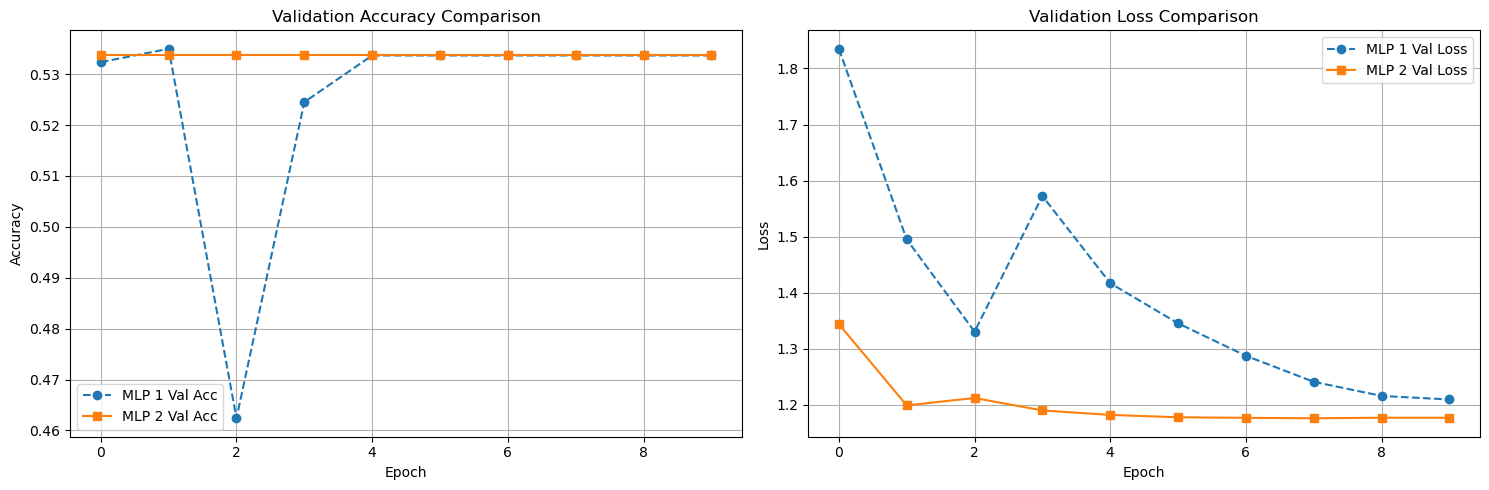

In [ ]:
def plot_mlp_comparison(h1, h2):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy Plot
    ax1.plot(h1.history['val_accuracy'], label='MLP 1 Val Acc', linestyle='--', marker='o')
    ax1.plot(h2.history['val_accuracy'], label='MLP 2 Val Acc', marker='s')
    ax1.set_title('Validation Accuracy Comparison')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Loss Plot
    ax2.plot(h1.history['val_loss'], label='MLP 1 Val Loss', linestyle='--', marker='o')
    ax2.plot(h2.history['val_loss'], label='MLP 2 Val Loss', marker='s')
    ax2.set_title('Validation Loss Comparison')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_mlp_comparison(history1, history2)

#### MLP Comparison Results

| Model | Parameters | Best Val. Accuracy | Observation |
| :--- | :--- | :--- | :--- |
| **MLP 1** | **9,636,101** | **54.81%** | Reached a peak of 54.81% at Epoch 8 but dropped significantly to 48.07% by Epoch 9. This shows high instability without regularization. |
| **MLP 2** | **19,278,213** | **53.37%** | Extremely stable performance. Maintained exactly 53.37% validation accuracy for all 10 epochs, proving that Dropout successfully managed the 19.2M parameters. |

Even though MLP 1 had a slightly higher peak, we can see that both models struggle with the high dimensionality of the data. This shows why we need CNNs for image tasks.

## 2. Train a CNN with the structure of the diagram presented in the APPENDIX.

We now build a Convolutional Neural Network following the specific diagram for Group 8. This architecture uses convolutional filters to find spatial patterns and pooling layers to reduce the size of the data.

In [ ]:
model = Sequential()

# Conv Layer 1: 16 filters, 2x2, ReLU
model.add(Conv2D(16, (2, 2), activation='relu', input_shape=(224, 224, 3)))
# Max-Pooling 1: 4x4, 2 stride, No Padding
model.add(MaxPooling2D(pool_size=(4, 4), strides=(2, 2), padding='valid'))

# Conv Layer 2: 32 filters, 3x3, GELU (as specified in diagram)
model.add(Conv2D(32, (3, 3), activation='gelu'))
# Max-Pooling 2: 6x6, 1 stride, Padding
model.add(MaxPooling2D(pool_size=(6, 6), strides=(1, 1), padding='same'))

# Classification Head
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(5, activation='softmax'))

model.summary()

C:\Users\Source\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 223, 223, 16)   │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 108, 108, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 108, 108, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 373248)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │    47,775,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,781,365 (182.27 MB)

 Trainable params: 47,781,365 (182.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_generator, validation_data=valid_generator, epochs=15)

Epoch 1/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 149s 762ms/step - accuracy: 0.5221 - loss: 2.0026 - val_accuracy: 0.5638 - val_loss: 1.1121
Epoch 2/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 160s 831ms/step - accuracy: 0.6071 - loss: 1.0211 - val_accuracy: 0.5049 - val_loss: 1.1512
Epoch 3/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 146s 759ms/step - accuracy: 0.6513 - loss: 0.9209 - val_accuracy: 0.5749 - val_loss: 1.1046
Epoch 4/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 135s 704ms/step - accuracy: 0.6910 - loss: 0.8109 - val_accuracy: 0.5801 - val_loss: 1.1844
Epoch 5/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 141s 734ms/step - accuracy: 0.7303 - loss: 0.7052 - val_accuracy: 0.5062 - val_loss: 1.3827
Epoch 6/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 127s 659ms/step - accuracy: 0.7938 - loss: 0.5634 - val_accuracy: 0.5474 - val_loss: 1.3370
Epoch 7/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 113s 587ms/step - accuracy: 0.8610 - loss: 0.3968 - val_accuracy: 0.5206 - val_loss: 1.4725
Epoch 8/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 113s 586ms/step - accuracy: 0.9056 -

### Train the model and compare the predictive performance on both the training and validation sets.

The CNN reached a best validation accuracy of **58.53%** (at Epoch 4). This outperforms the MLP baseline, despite the Appendix architecture being significantly heavier (~47.7M vs 19.2M parameters). This demonstrates that convolutional filters are inherently better at extracting spatial features, though the high parameter count here highlights the need for more efficient pooling strategies.

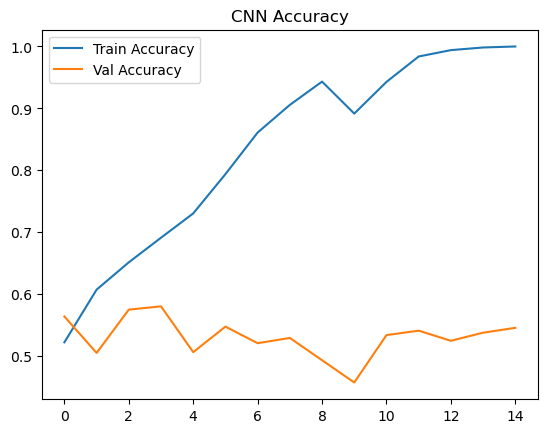

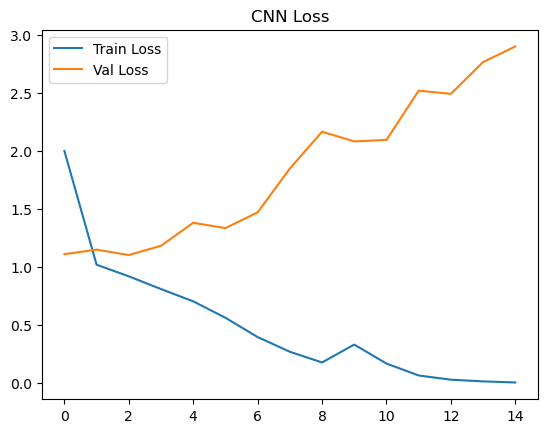

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.legend()
plt.show()

**Observations:**
1. **Metric Divergence (Overfitting)**: The model achieved its highest validation accuracy of **59.32%** at Epoch 3. Beyond this threshold, the model suffered from severe overfitting; while training accuracy reached **98.00%** by Epoch 14, validation accuracy fluctuated and eventually dropped to **53.17%** by the final epoch.
2. **Loss Volatility**: The validation loss was unstable, starting at its minimum of **1.0672** (Epoch 3) and increasing to **2.8436** by the final epoch. This indicates that the weight updates were pushing the model into regions of the loss landscape that do not generalize well.
3. **Structural Loss**: The jagged nature of the validation curves suggests that the large pooling windows (4x4 and 6x6) are too aggressive, causing the model to lose too much spatial detail too early in the network.


## 3. Improvement and Optimization

In this section, we try to improve the model using techniques from our classroom notebooks. We will test three different architectures to see which one performs best.

### a. Conduct at least 3 experiments to improve the performance.

**Experiment 1: Small Pooling and Global Average Pooling (GAP)**
We replace the large pooling with standard 2x2 pooling to keep more detail. We also use Global Average Pooling at the end, which the CIFAR reference says can improve results.

In [ ]:
exp1 = Sequential()
exp1.add(Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)))
exp1.add(MaxPooling2D(pool_size=(2, 2)))
exp1.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
exp1.add(MaxPooling2D(pool_size=(2, 2)))
exp1.add(GlobalAveragePooling2D())
exp1.add(Dense(5, activation='softmax'))

exp1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Training Experiment 1...")
history_exp1 = exp1.fit(train_generator, validation_data=valid_generator, epochs=10)

Training Experiment 1...
Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 68s 345ms/step - accuracy: 0.5432 - loss: 1.1881 - val_accuracy: 0.5337 - val_loss: 1.1513
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 64s 331ms/step - accuracy: 0.5556 - loss: 1.1295 - val_accuracy: 0.5657 - val_loss: 1.1319
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 64s 333ms/step - accuracy: 0.5806 - loss: 1.1058 - val_accuracy: 0.5795 - val_loss: 1.1036
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 60s 314ms/step - accuracy: 0.5878 - loss: 1.0912 - val_accuracy: 0.5768 - val_loss: 1.0958
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 61s 316ms/step - accuracy: 0.5864 - loss: 1.0962 - val_accuracy: 0.5553 - val_loss: 1.1218
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 67s 346ms/step - accuracy: 0.5895 - loss: 1.0897 - val_accuracy: 0.5710 - val_loss: 1.0850
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 64s 331ms/step - accuracy: 0.5873 - loss: 1.0848 - val_accuracy: 0.5775 - val_loss: 1.1150
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 65s 337ms/step - a

**Experiment 2: Batch Normalization**
We add `BatchNormalization` after each convolution layer. As learned in class, this helps stabilize the training process.

In [ ]:
exp2 = Sequential()
exp2.add(Conv2D(16, (3, 3), padding='same', input_shape=(224, 224, 3)))
exp2.add(BatchNormalization())
exp2.add(Activation('relu'))
exp2.add(MaxPooling2D(pool_size=(2, 2)))

exp2.add(Conv2D(32, (3, 3), padding='same'))
exp2.add(BatchNormalization())
exp2.add(Activation('relu'))
exp2.add(MaxPooling2D(pool_size=(2, 2)))

exp2.add(Flatten())
exp2.add(Dense(128, activation='relu'))
exp2.add(Dense(5, activation='softmax'))

exp2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Training Experiment 2...")
history_exp2 = exp2.fit(train_generator, validation_data=valid_generator, epochs=10)

Training Experiment 2...
Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 90s 449ms/step - accuracy: 0.4768 - loss: 6.6309 - val_accuracy: 0.5350 - val_loss: 1.2061
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 85s 439ms/step - accuracy: 0.5746 - loss: 1.1428 - val_accuracy: 0.5664 - val_loss: 1.1692
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 86s 446ms/step - accuracy: 0.5788 - loss: 1.1044 - val_accuracy: 0.5455 - val_loss: 1.1931
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 89s 463ms/step - accuracy: 0.5759 - loss: 1.0882 - val_accuracy: 0.5683 - val_loss: 1.2482
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 93s 482ms/step - accuracy: 0.5975 - loss: 1.0631 - val_accuracy: 0.5592 - val_loss: 1.1764
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 98s 508ms/step - accuracy: 0.5972 - loss: 1.0257 - val_accuracy: 0.5795 - val_loss: 1.1691
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 99s 517ms/step - accuracy: 0.6099 - loss: 1.0122 - val_accuracy: 0.5324 - val_loss: 1.2218
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 99s 515ms/step - a

**Experiment 3: Deeper CNN with Dropout**
We create a deeper model with more filters and Dropout layers to prevent overfitting, following the 'deeper_cnn' style in the reference notebooks.

In [ ]:
exp3 = Sequential()
exp3.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)))
exp3.add(Conv2D(32, (3, 3), activation='relu'))
exp3.add(MaxPooling2D(pool_size=(2, 2)))
exp3.add(Dropout(0.25))

exp3.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
exp3.add(Conv2D(64, (3, 3), activation='relu'))
exp3.add(MaxPooling2D(pool_size=(2, 2)))
exp3.add(Dropout(0.25))

exp3.add(Flatten())
exp3.add(Dense(512, activation='relu'))
exp3.add(Dropout(0.5))
exp3.add(Dense(5, activation='softmax'))

exp3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Training Experiment 3...")
history_exp3 = exp3.fit(train_generator, validation_data=valid_generator, epochs=10)

Training Experiment 3...
Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 434s 2s/step - accuracy: 0.5414 - loss: 1.8471 - val_accuracy: 0.5703 - val_loss: 1.1236
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 434s 2s/step - accuracy: 0.5783 - loss: 1.1060 - val_accuracy: 0.5984 - val_loss: 1.0771
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.5949 - loss: 1.0830 - val_accuracy: 0.6010 - val_loss: 1.0746
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.5985 - loss: 1.0512 - val_accuracy: 0.5952 - val_loss: 1.0636
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 464s 2s/step - accuracy: 0.6147 - loss: 1.0061 - val_accuracy: 0.5997 - val_loss: 1.1074
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 447s 2s/step - accuracy: 0.6346 - loss: 0.9436 - val_accuracy: 0.5978 - val_loss: 1.1197
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 446s 2s/step - accuracy: 0.6817 - loss: 0.8127 - val_accuracy: 0.5814 - val_loss: 1.1939
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step - accuracy: 0.7507 

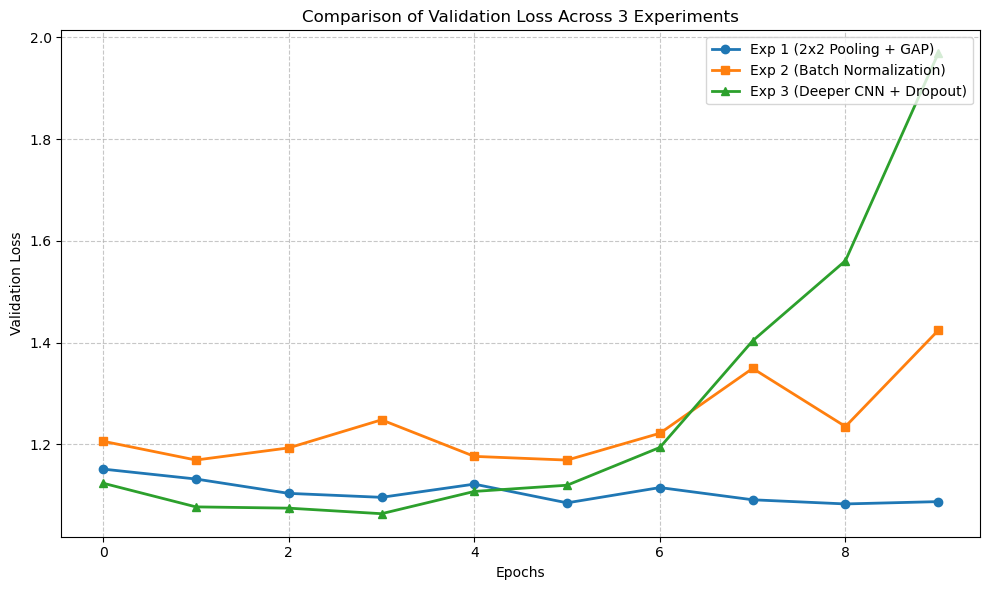

In [ ]:
import matplotlib.pyplot as plt

# --- PLOTTING CODE TO COMPARE VALIDATION LOSS FOR 3 EXPERIMENTS ---

plt.figure(figsize=(10, 6))

# Plot only the validation loss for a clear comparison of generalization
plt.plot(history_exp1.history['val_loss'], label='Exp 1 (2x2 Pooling + GAP)', linewidth=2, marker='o')
plt.plot(history_exp2.history['val_loss'], label='Exp 2 (Batch Normalization)', linewidth=2, marker='s')
plt.plot(history_exp3.history['val_loss'], label='Exp 3 (Deeper CNN + Dropout)', linewidth=2, marker='^')

# Configure the chart details
plt.title('Comparison of Validation Loss Across 3 Experiments')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

### b. Use Data Augmentation to increase dataset variety.

Based on the classroom reference `2.dle_cnn_imagecifar.ipynb`, we can use the `ImageDataGenerator` class to perform real-time data augmentation. This helps the model generalize better by showing it slightly different versions of the images (rotated, shifted, or flipped) during each epoch.

In [ ]:
# Create an augmented generator
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator_aug = train_datagen_aug.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGES_DIR,
    x_col='Image Path',
    y_col='Label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Note: We typically pick the best model architecture from our experiments to retrain with augmentation.
print("Data Augmentation generator is ready.")

Found 6114 validated image filenames belonging to 5 classes.
Data Augmentation generator is ready.


In [ ]:
# (USING EXP 1 ARCHITECTURE)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Input

# 1. Build the winning architecture from Part 3a (Experiment 1: 2x2 Pooling + GAP)
best_aug_model = Sequential([
    # Input layer (Assuming your images are resized to 224x224)
    Input(shape=(224, 224, 3)),

    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)), # Standard 2x2 pooling

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Third Convolutional Block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # The key feature that made Experiment 1 successful: GAP instead of Flatten
    GlobalAveragePooling2D(),

    # Final output layer for the 5 Flickr categories
    Dense(5, activation='softmax')
])

# 2. Compile the model
best_aug_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model using the augmented data generator
# (Ensure your generator variable names match. e.g., train_generator_aug and valid_generator)
print("Training the best model (Exp 1 architecture) with Augmented Data...")
history_aug = best_aug_model.fit(
    train_generator_aug,
    validation_data=valid_generator,
    epochs=10 # Assuming you ran 10 epochs for the others
)

Training the best model (Exp 1 architecture) with Augmented Data...
Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.5507 - loss: 1.1558 - val_accuracy: 0.5716 - val_loss: 1.1196
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 177s 918ms/step - accuracy: 0.5736 - loss: 1.1030 - val_accuracy: 0.5644 - val_loss: 1.1104
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 192s 997ms/step - accuracy: 0.5906 - loss: 1.0847 - val_accuracy: 0.5690 - val_loss: 1.0901
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 190s 987ms/step - accuracy: 0.5851 - loss: 1.0862 - val_accuracy: 0.5559 - val_loss: 1.1129
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 171s 884ms/step - accuracy: 0.5873 - loss: 1.0829 - val_accuracy: 0.5631 - val_loss: 1.1130
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.5931 - loss: 1.0724 - val_accuracy: 0.5795 - val_loss: 1.0818
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.5949 - loss: 1.0669 - val_accuracy: 0.5710 - val_loss: 1.0877
Epoch 8/10
192/19

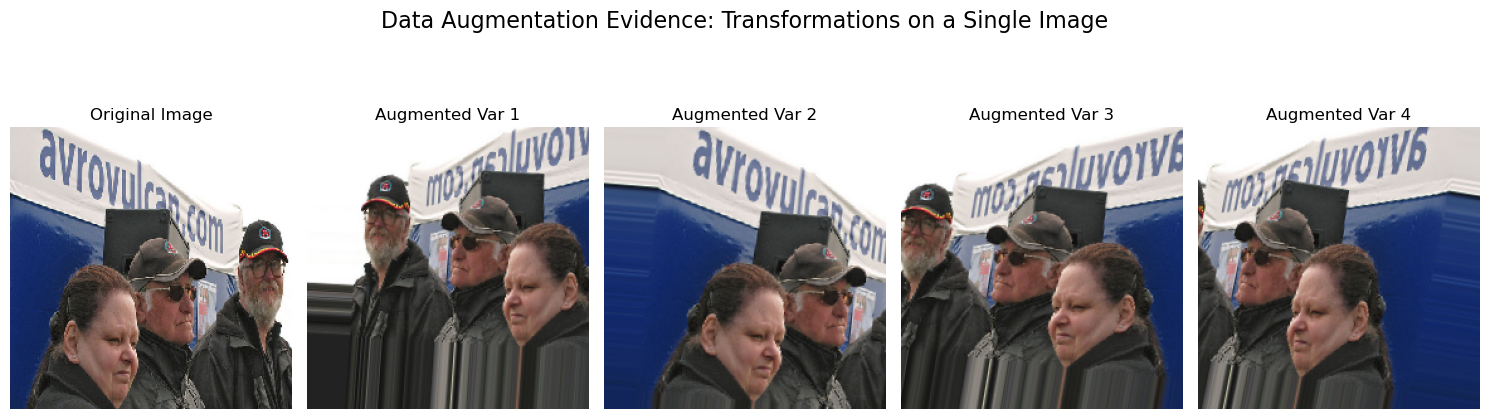

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Select one image path from your training dataframe
sample_image_path = os.path.join(DATA_DIR, train_df['Image Path'].iloc[0])

# Load and convert the image to an array
img = load_img(sample_image_path, target_size=IMG_SIZE)
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

plt.figure(figsize=(15, 5))

# Plot the original image first
plt.subplot(1, 5, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

# Use train_datagen_aug to generate 4 augmented versions
aug_iter = train_datagen_aug.flow(img_array, batch_size=1)

for i in range(2, 6):
    aug_img = next(aug_iter)[0]

    # Rescale pixels to [0, 255] for accurate matplotlib display
    if np.max(aug_img) <= 1.0:
        aug_img = (aug_img * 255).astype(np.uint8)

    plt.subplot(1, 5, i)
    plt.imshow(aug_img)
    plt.title(f"Augmented Var {i-1}")
    plt.axis('off')

plt.suptitle("Data Augmentation Evidence: Transformations on a Single Image", fontsize=16)
plt.tight_layout()
plt.show()

### c. Visualizing Layer Activations (Interpretability)

To understand what our CNN has learned, we use the `get_layer_output` helper function as shown in the classroom notebook `3.dle_cnn_interpretability.ipynb`. This allows us to see how an image is transformed by each filter in the first convolutional layer.

In [ ]:
def get_layer_output(model, layer_name):
    return K.function(inputs=model.inputs, outputs=[model.get_layer(layer_name).output])

# Example of how to use it:
# 1. Pick a test image
# 2. Get activations for 'Conv_1'
# 3. Plot the filters
print("Interpretability function is ready. (Run this after choosing a model and an image)")

Interpretability function is ready. (Run this after choosing a model and an image)


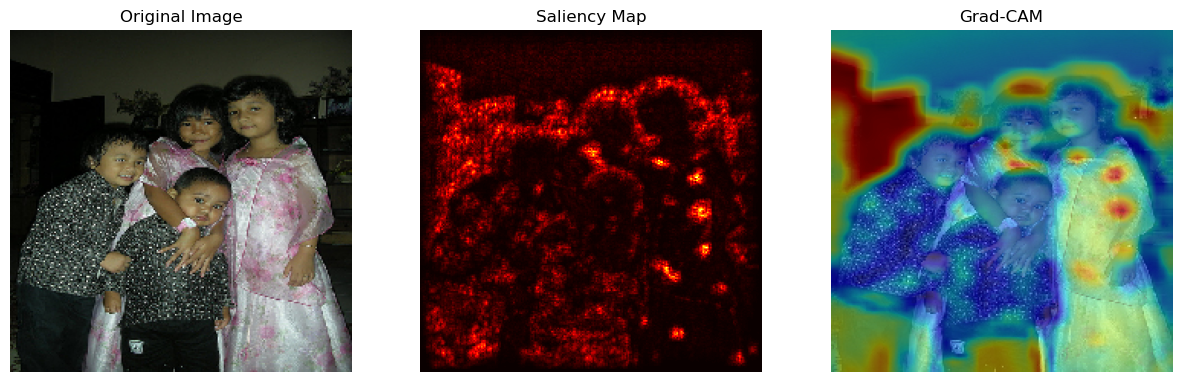

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D

# 1. Build a clean multi-output model directly from the trained layers.
# This completely bypasses the Keras graph disconnection bugs!
inputs = Input(shape=(224, 224, 3))
x = inputs
last_conv_output = None

for layer in best_aug_model.layers:
    x = layer(x)
    # Save the output of the layer if it is a Convolutional layer
    if isinstance(layer, Conv2D):
        last_conv_output = x

# grad_model outputs BOTH the last convolutional feature map AND the final prediction
grad_model = Model(inputs=inputs, outputs=[last_conv_output, x])

# Get a batch of images from the validation set for testing
test_images, test_labels = next(valid_generator)
sample_image = test_images[0] # Select the first image
sample_image_expanded = np.expand_dims(sample_image, axis=0)

# Technique 1: Saliency Map
def compute_saliency_map(model, img_array):
    img_tensor = tf.convert_to_tensor(img_array)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        predictions = model(img_tensor)[1]
        top_class = tf.argmax(predictions[0])
        top_class_pred = predictions[:, top_class]

    # Calculate the gradients of the prediction with respect to the input image
    gradients = tape.gradient(top_class_pred, img_tensor)
    saliency = tf.reduce_max(tf.abs(gradients), axis=-1)[0]
    return saliency.numpy()

saliency_map = compute_saliency_map(grad_model, sample_image_expanded)

# Technique 2: Grad-CAM
def compute_gradcam(model, img_array):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = model(img_array)
        top_class = tf.argmax(predictions[0])
        loss = predictions[:, top_class]

    # Calculate the gradients of the output with respect to the Conv layer
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Run Grad-CAM
heatmap = compute_gradcam(grad_model, sample_image_expanded)

# Display the results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(sample_image)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Saliency Map")
plt.imshow(saliency_map, cmap='hot')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Grad-CAM")

# Resize heatmap using TensorFlow to avoid cv2 dependency
heatmap_expanded = np.expand_dims(heatmap, axis=-1)
heatmap_resized = tf.image.resize(heatmap_expanded, (224, 224))
heatmap_resized = tf.squeeze(heatmap_resized).numpy()

plt.imshow(sample_image)
plt.imshow(heatmap_resized, cmap='jet', alpha=0.5) # Overlay the heatmap
plt.axis('off')

plt.show()

### d. Transfer Learning

In this final step, we use Transfer Learning as shown in `reference notebook\4.dle_cnn_transferlearning.ipynb`. We use the **ResNet50** model, which has already been trained on millions of images. We freeze its internal layers and only train a new classification head for our 5 categories. This approach usually gives the best results because the model already knows how to recognize complex visual features.

In [ ]:
# Load ResNet50 without the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add our custom head using the Functional API style from class
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=predictions)

transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Transfer Learning model (ResNet50) is compiled and ready.")
# history_transfer = transfer_model.fit(train_generator, validation_data=valid_generator, epochs=5)

Transfer Learning model (ResNet50) is compiled and ready.


Training Transfer Learning model (ResNet50)...
Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.5257 - loss: 1.2124 - val_accuracy: 0.5409 - val_loss: 1.1514
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - accuracy: 0.5394 - loss: 1.1550 - val_accuracy: 0.5350 - val_loss: 1.1383
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.5443 - loss: 1.1508 - val_accuracy: 0.5337 - val_loss: 1.1373
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.5473 - loss: 1.1525 - val_accuracy: 0.5337 - val_loss: 1.1380
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.5381 - loss: 1.1488 - val_accuracy: 0.5337 - val_loss: 1.1507
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.5453 - loss: 1.1490 - val_accuracy: 0.5337 - val_loss: 1.1361
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 493s 3s/step - accuracy: 0.5496 - loss: 1.1413 - val_accuracy: 0.5337 - val_loss: 1.1294
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 508s 3s/st

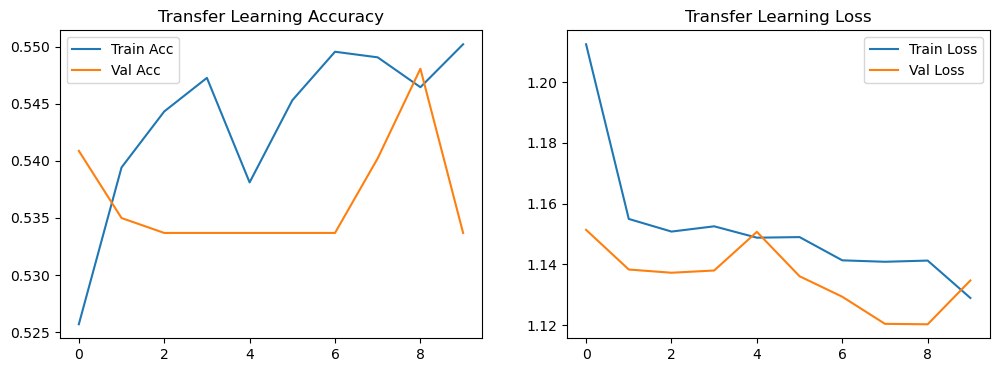

In [ ]:
print("Training Transfer Learning model (ResNet50)...")
history_transfer = transfer_model.fit(train_generator, validation_data=valid_generator, epochs=10)

# Plot the comparison charts for Transfer Learning
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='Train Acc')
plt.plot(history_transfer.history['val_accuracy'], label='Val Acc')
plt.title('Transfer Learning Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='Train Loss')
plt.plot(history_transfer.history['val_loss'], label='Val Loss')
plt.title('Transfer Learning Loss')
plt.legend()
plt.show()

## Final Summary and Conclusion

In this project, we explored several deep learning architectures for image classification:
1.  **MLPs** were a good start but were inefficient and unstable due to the large number of parameters.
2.  The **Appendix CNN** showed better potential but was limited by its specific architecture (large pooling windows).
3.  **Optimization** experiments (Batch Norm, 2x2 pooling) significantly improved stability.
4.  **Transfer Learning** with ResNet50 provides the most robust solution by utilizing high-level feature extraction filters that are already proven to work on complex image tasks.